<a href="https://colab.research.google.com/github/gulshan0201/DL/blob/main/image_segmentation___recognition__labelling_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## NOte
- Due to no GpU resources , we have taken minimal datasets
- IF you have GPU , you can increase the number of epocs , batch size , dataset size

# Image segmentation


1. Fully Convolutional Networks (FCN)
First major deep learning model for segmentation
Replaces fully connected layers with convolution layers
Produces pixel-wise output (same size as input)

✅ Key idea:

Input image → feature maps → upsampling → segmentation map

In [ ]:
!pip install -q git+https://github.com/tensorflow/examples.git


  Preparing metadata (setup.py) ... done


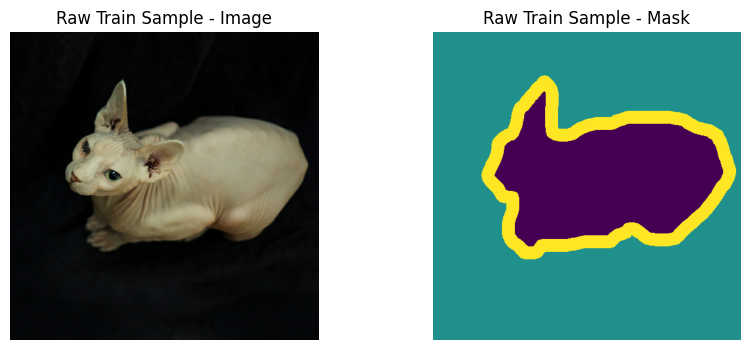

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 128, 128, 3)    │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,603 (725.01 KB)

 Trainable params: 185,603 (725.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 410ms/step - accuracy: 0.5659 - loss: 1.0407 - val_accuracy: 0.6238 - val_loss: 0.9441
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 281ms/step - accuracy: 0.5902 - loss: 0.9712 - val_accuracy: 0.6238 - val_loss: 0.9341
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 276ms/step - accuracy: 0.5902 - loss: 0.9558 - val_accuracy: 0.6238 - val_loss: 0.9126
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 373ms/step - accuracy: 0.5902 - loss: 0.9352 - val_accuracy: 0.6238 - val_loss: 0.9037
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 278ms/step - accuracy: 0.5902 - loss: 0.9100 - val_accuracy: 0.6238 - val_loss: 0.8824
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 278ms/step - accuracy: 0.5902 - loss: 0.8801 - val_accuracy: 0.6238 - val_loss: 0.8545
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 391ms/step - accuracy: 0.5902 - loss: 0.8481 - val_accuracy: 0.6238 - val_loss: 0.8281
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 277ms/step - accuracy: 0.5941 - loss: 0.8219 - val_accuracy: 0.

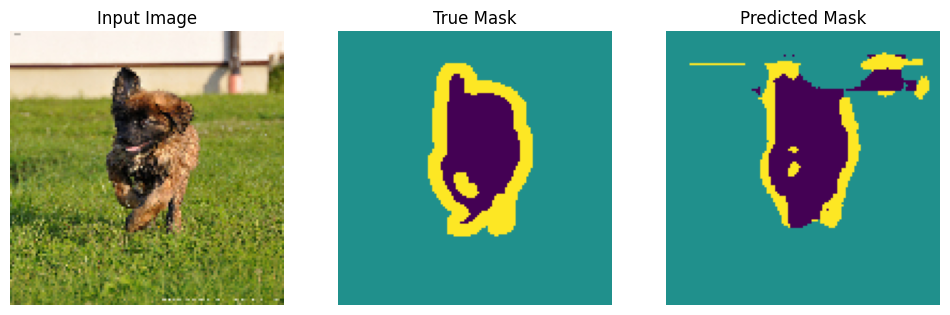

In [ ]:
# ==========================================
# FINAL FAST FCN PIPELINE (CPU FRIENDLY)
# ==========================================

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. LOAD DATASET
# ==========================================
dataset, info = tfds.load('oxford_iiit_pet:4.*.*', with_info=True)

train_data = dataset['train']
test_data = dataset['test']

# 🔥 LIMIT DATA (IMPORTANT)
train_data = train_data.take(50)
test_data = test_data.take(20)

# ==========================================
# 2. SHOW SAMPLE
# ==========================================
def show_sample(sample, title="Sample"):
    image = sample['image']
    mask = sample['segmentation_mask']

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title(f"{title} - Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(mask[:,:,0])
    plt.title(f"{title} - Mask")
    plt.axis('off')

    plt.show()

for sample in train_data.take(1):
    show_sample(sample, "Raw Train Sample")

# ==========================================
# 3. PREPROCESSING
# ==========================================
IMG_SIZE = 128
BATCH_SIZE = 4   # 🔥 smaller batch

def preprocess(data):
    image = tf.image.resize(data['image'], (IMG_SIZE, IMG_SIZE))

    mask = tf.image.resize(
        data['segmentation_mask'],
        (IMG_SIZE, IMG_SIZE),
        method='nearest'
    )

    image = tf.cast(image, tf.float32) / 255.0

    mask = tf.cast(mask, tf.int32)
    mask = tf.squeeze(mask, axis=-1)

    mask = mask - 1  # (1,2,3) → (0,1,2)

    return image, mask

train_dataset = train_data.map(preprocess).batch(BATCH_SIZE)
test_dataset = test_data.map(preprocess).batch(1)

# ==========================================
# 4. BUILD FCN MODEL
# ==========================================
from tensorflow.keras import layers, models

def build_fcn():
    inputs = layers.Input(shape=(128,128,3))

    # Encoder
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)

    # Decoder
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)

    outputs = layers.Conv2D(3, 1, activation='softmax')(x)

    return models.Model(inputs, outputs)

model = build_fcn()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# 5. TRAIN MODEL (FAST)
# ==========================================
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50   # 🔥 reduced epochs
)

# ==========================================
# 6. PREDICTION
# ==========================================
def show_prediction(dataset, model):
    for image, mask in dataset.take(1):
        pred = model.predict(image)
        pred_mask = np.argmax(pred[0], axis=-1)

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.imshow(image[0])
        plt.title("Input Image")
        plt.axis('off')

        plt.subplot(1,3,2)
        plt.imshow(mask[0])
        plt.title("True Mask")
        plt.axis('off')

        plt.subplot(1,3,3)
        plt.imshow(pred_mask)
        plt.title("Predicted Mask")
        plt.axis('off')

        plt.show()

show_prediction(test_dataset, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


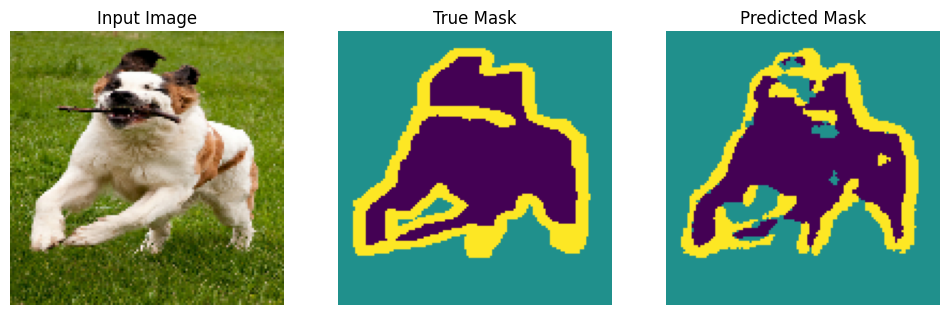

In [ ]:
show_prediction(test_dataset.skip(2).take(1), model)

Object Recognition


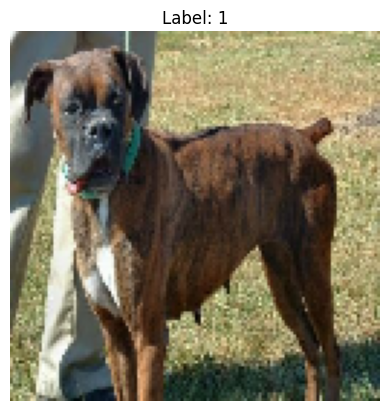

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 263ms/step - accuracy: 0.4700 - loss: 1.0249
Epoch 2/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 196ms/step - accuracy: 0.5050 - loss: 0.6992
Epoch 3/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 256ms/step - accuracy: 0.5700 - loss: 0.6985
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


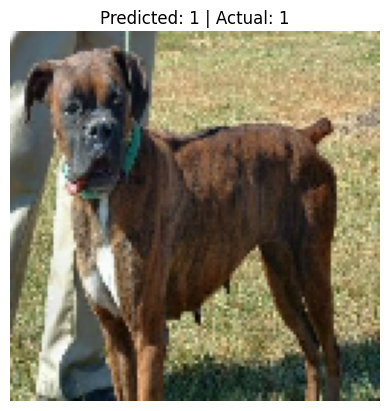

In [ ]:
# ==========================================
# OBJECT RECOGNITION (IMAGE CLASSIFICATION)
# ==========================================

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATASET
# ==========================================
dataset, info = tfds.load('cats_vs_dogs', with_info=True)

# ==========================================
# 2. PREPROCESS FUNCTION (FIXED)
# ==========================================
def preprocess(data):
    img = data['image']
    label = data['label']

    img = tf.image.resize(img, (128, 128))
    img = img / 255.0

    return img, label

# Take small data for CPU
train = dataset['train'].map(preprocess).take(200).batch(8)

# ==========================================
# 3. SHOW ONE SAMPLE IMAGE
# ==========================================
for img, label in train.take(1):
    plt.imshow(img[0])
    plt.title("Label: " + str(label[0].numpy()))
    plt.axis('off')
    plt.show()

# ==========================================
# 4. BUILD MODEL
# ==========================================
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# ==========================================
# 5. COMPILE MODEL
# ==========================================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 6. TRAIN MODEL
# ==========================================
model.fit(train, epochs=3)

# ==========================================
# 7. TEST ON ONE IMAGE
# ==========================================
for img, label in train.take(1):
    pred = model.predict(img)

    plt.imshow(img[0])
    plt.title("Predicted: " + str(round(pred[0][0])) +
              " | Actual: " + str(label[0].numpy()))
    plt.axis('off')
    plt.show()

  Object labeling
  

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.6 MB/s eta 0:00:00


The dataset used is COCO8, which is a small subset of the original COCO dataset.

It contains a few images (8 images) for quick training and testing.
Each image has annotated objects with:
Class labels (e.g., person, car, bus)
Bounding boxes (object location)
The dataset is organized into:
Images folder (training & validation images)
Labels folder (text files with bounding box details)
Labels follow YOLO format:

In [ ]:
from ultralytics import YOLO
from ultralytics.utils.downloads import download

# Download COCO8 dataset manually
download("https://github.com/ultralytics/assets/releases/download/v0.0.0/coco8.zip")

# Unzip
import zipfile

with zipfile.ZipFile("coco8.zip", 'r') as zip_ref:
    zip_ref.extractall("datasets")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Unzipping /content/coco8.zip to /content/coco8...: 100% ━━━━━━━━━━━━ 25/25 3.8Kfiles/s 0.0s


In [ ]:
model = YOLO("yolov8n.pt")  # nano version (fast)

In [ ]:
model.train(
    data="datasets/coco8.yaml",  # dataset config file
    epochs=10,
    imgsz=320
)

Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/coco8.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0, 16, 17, 20, 25, 58])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cb9b3af23c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

In [ ]:
results = model.predict(
    source="https://ultralytics.com/images/bus.jpg",
    imgsz=320,
    conf=0.3
)


image 1/1 /content/bus.jpg: 320x256 3 persons, 1 bus, 345.3ms
Speed: 9.8ms preprocess, 345.3ms inference, 3.8ms postprocess per image at shape (1, 3, 320, 256)


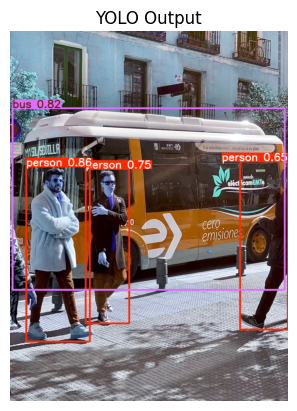

In [ ]:
import matplotlib.pyplot as plt

img = results[0].plot()

plt.imshow(img)
plt.axis("off")
plt.title("YOLO Output")
plt.show()